In [201]:
import csv
import math
import random
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [264]:

def clean_data(data_path):
    # Cleaining data
    # Read the CSV file into a DataFrame
    df = pd.read_csv(data_path)

    # Remove the first and third columns
    columns_to_remove = [1, 4,5,22,24,25,23,9,8,14,15]
    df = df.drop(df.columns[columns_to_remove], axis=1)

    # Write the modified data to a new CSV file
    clean_data_path = 'clean_data.csv'
    df.to_csv(clean_data_path, index=False)
    return clean_data_path

def load_data(filename):
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)  # skip header row
        data = list(reader)

    return data


def preprocess_data(data):
    # Remove irrelevant columns like 'id' and convert float values
    columns_to_remove = [0, 4, 5, 22, 24, 25, 23, 9, 8, 14, 15]
    for row in data:
        for column_index in sorted(columns_to_remove, reverse=True):
            del row[column_index]
        for i in range(1, len(row)):
            row[i] = float(row[i])  # Convert values to float

    # Convert class labels to numeric values
    class_mapping = {'M': 1, 'B': 0}
    for row in data:
        row[0] = class_mapping[row[0]]
    
    random.shuffle(data)
    return data


def split_data(data, split_ratio):
    train_size = int(len(data) * split_ratio)
    train_set = data[:train_size]
    test_set = data[train_size:]
    return train_set, test_set


def separate_by_class(data):
    classes = {}
    
    for row in data:
        if row[0] not in classes:
            classes[row[0]] = []
        classes[row[0]].append(row[1:])
    
    return classes


def calculate_mean(column):
    return sum(column) / float(len(column))


def calculate_std_dev(column, mean):
    variance = sum([(x - mean) ** 2 for x in column]) / float(len(column))
    return math.sqrt(variance)


def summarize_data(data):
    summaries = [(calculate_mean(column), calculate_std_dev(column, calculate_mean(column))) 
                 for column in zip(*data)]
    return summaries


def summarize_by_class(data):
    summaries = {}
    
    for class_value, rows in data.items():
        summaries[class_value] = summarize_data(rows)
    
    return summaries


def calculate_probability(x, mean, std_dev):
    exponent = math.exp(-(math.pow(x - mean, 2) / (2 * math.pow(std_dev, 2))))
    return (1 / (math.sqrt(2 * math.pi) * std_dev)) * exponent


def calculate_class_probabilities(summaries, input_data):
    probabilities = {}

    for class_value, class_summaries in summaries.items():
        probabilities[class_value] = 1
        
        for i in range(len(class_summaries)):
            mean, std_dev = class_summaries[i]
            x = input_data[i]
            probabilities[class_value] *= calculate_probability(x, mean, std_dev)

    return probabilities


def predict(summaries, input_data):
    probabilities = calculate_class_probabilities(summaries, input_data)
    best_label, best_prob = None, -1
    
    for class_value, probability in probabilities.items():
        if best_label is None or probability > best_prob:
            best_label = class_value
            best_prob = probability
    
    return best_label


def get_predictions(summaries, test_data):
    predictions = []
    
    for row in test_data:
        result = predict(summaries, row[1:])
        predictions.append(result)
    
    return predictions


def get_accuracy(test_data, predictions):
    correct = 0
    
    for i in range(len(test_data)):
        if test_data[i][0] == predictions[i]:
            correct += 1
    
    return (correct / float(len(test_data))) * 100.0



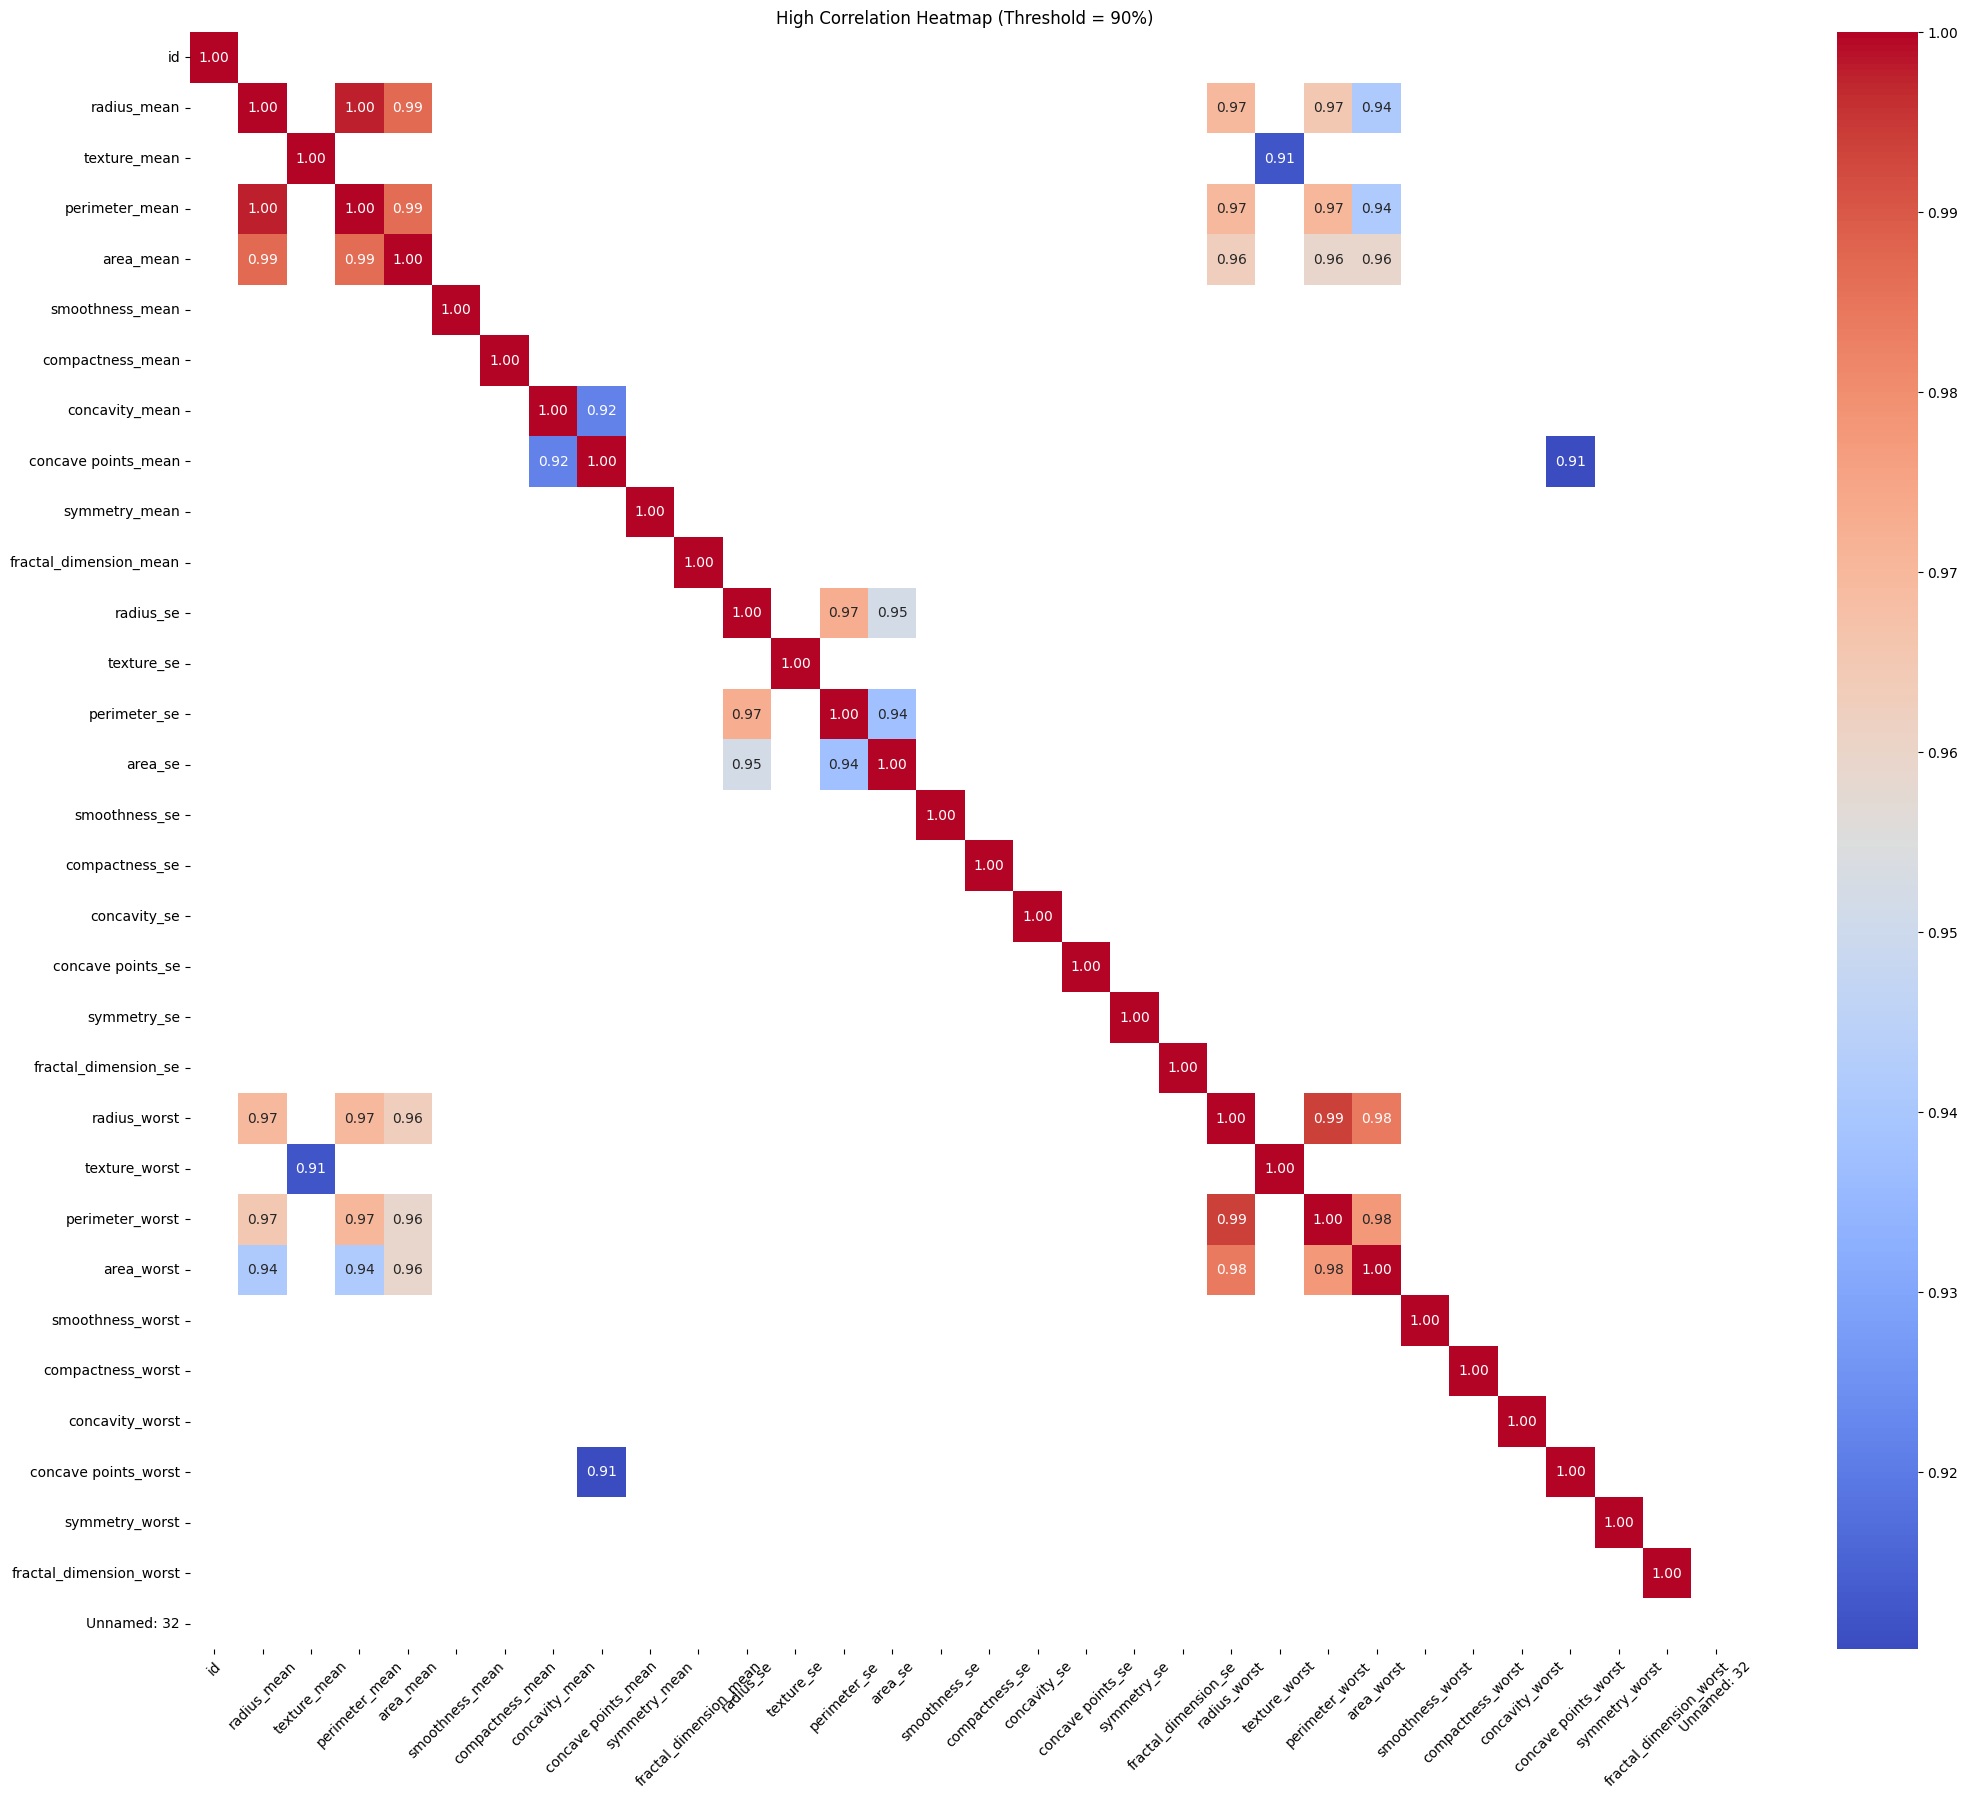

In [242]:
# Read the CSV file into a DataFrame
df = pd.read_csv('data.csv')

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Filter the correlation matrix based on the threshold (90%)
threshold = 0.9
high_correlation = correlation_matrix[correlation_matrix.abs() > threshold]

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(25, 21))

# Create the heatmap
sns.heatmap(high_correlation, cmap='coolwarm', annot=True, fmt=".2f", ax=ax)

# Add a title
ax.set_title('High Correlation Heatmap (Threshold = 90%)')

# Rotate the x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Show the plot
plt.show()

Self implemented Naive Bayes Results:
__________________________________________
Confusion Matrix:
[[65  6]
 [ 2 41]]
Accuracy: 92.98%
Recall: 95.35%


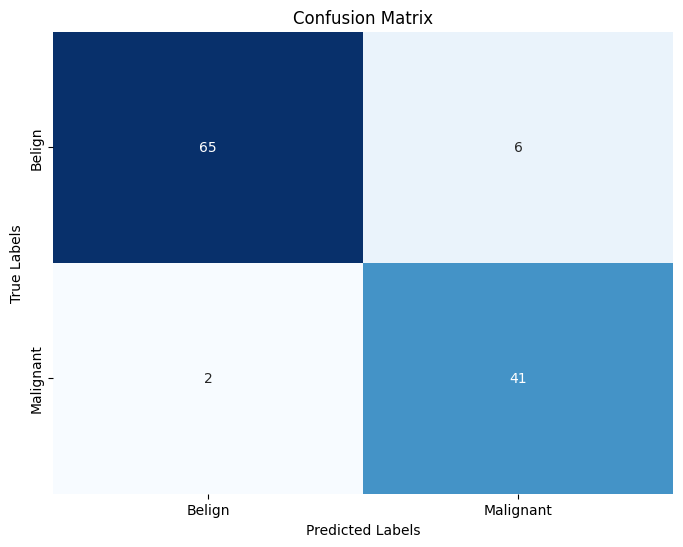

In [277]:
# Load and preprocess the data
# clean_data_path = clean_data('data.csv')
data = load_data('data.csv')
preprocessed_data = preprocess_data(data)

# Split the preprocessed data into training and testing sets
train_set, test_set = split_data(preprocessed_data, 0.8)

# Prepare the Naive Bayes classifier using training set
class_summaries = summarize_by_class(separate_by_class(train_set))

# Make predictions on the testing set
predictions = get_predictions(class_summaries, test_set)

# Get ground truth labels from the testing set
true_labels = [row[0] for row in test_set]

# Calculate confusion matrix
confusion_mat = confusion_matrix(true_labels, predictions)

# Calculate accuracy
accuracy = get_accuracy(test_set, predictions)

# Calculate recall (sensitivity)
recall = confusion_mat[1, 1] / (confusion_mat[1, 0] + confusion_mat[1, 1])

print("Self implemented Naive Bayes Results:")
print("__________________________________________")
print("Confusion Matrix:")
print(confusion_mat)
print("Accuracy: {:.2f}%".format(accuracy))
print("Recall: {:.2f}%".format(recall*100))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Belign', 'Malignant'], yticklabels=['Belign', 'Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Scikit-Learn Results:
__________________________________________
Confusion Matrix:
[[66  5]
 [ 2 41]]
Accuracy: 93.86%
Recall: 95.35%


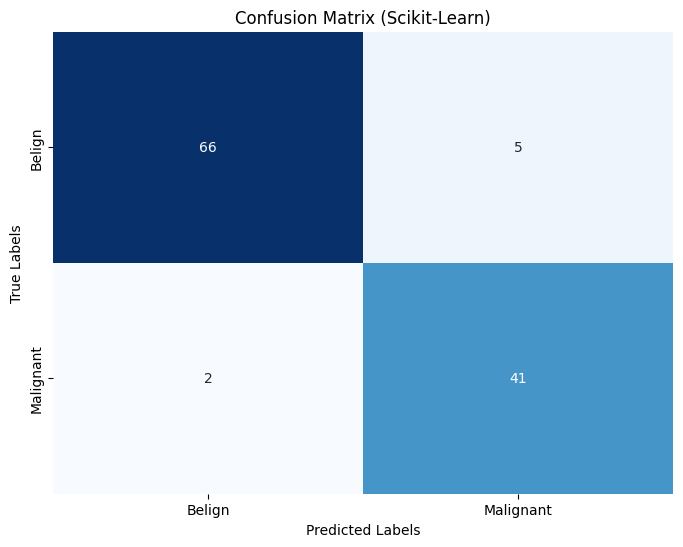

In [278]:
X_train = [row[1:] for row in train_set]
y_train = [row[0] for row in train_set]
classifier = GaussianNB()
classifier.fit(X_train, y_train)

X_test = [row[1:] for row in test_set]
predictions = classifier.predict(X_test)

true_labels = [row[0] for row in test_set]

confusion_mat = confusion_matrix(true_labels, predictions)
accuracy = accuracy_score(true_labels, predictions)

recall = confusion_mat[1, 1] / (confusion_mat[1, 0] + confusion_mat[1, 1])

print("Scikit-Learn Results:")
print("__________________________________________")
print("Confusion Matrix:")
print(confusion_mat)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Recall: {:.2f}%".format(recall * 100))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Belign', 'Malignant'], yticklabels=['Belign', 'Malignant'])
plt.title("Confusion Matrix (Scikit-Learn)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()